<a href="https://colab.research.google.com/github/ODZ-UJF-AV-CR/SPACEDOS-ISS-RadLab/blob/main/SPACEDOS_ISS_2020_power_interruption.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SPACEDOS02

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta, timezone
from IPython.display import Image as ImageDisp
from pandas import DataFrame
import string
import os
import glob
import matplotlib.pyplot as plt
import matplotlib
import gdown
%matplotlib inline

# SPACEDOS ISS 2020-2021

Launch Soyuz MS-17: 14 October 2020, 05:45:04
- Launch site: Baikonur
- Launch pad: Site 31
- Altitude: 420 km
- Inclination: 51,6°

### Docking ISS: 14 October 2020, 08:48:47 UTC
### Undocking ISS: 17 April 2021, 01:34 UTC
Landing Soyuz MS-17: 17 April 2021, 04:55 UTC
- Landing site: Kazakh Steppe

_Note: Gaps in measurement after measurement number 678000_

## Flux and Doserate

In [2]:
# Copy data from iss2019.csv to temporary file
file_id = "1su0SVjxOkHmytRWlOZ0n2El4FgzalUuL"
gdown.download(f"https://drive.google.com/uc?id={file_id}", "data.csv", quiet=True)

'data.csv'

In [15]:
# Read temporary file
rc = pd.read_csv(
    "data.csv",
    sep=",",
    header=0,
    comment="*",
)
for col in ["abs_time", "corr_time"]:
    rc[col] = pd.to_datetime(rc[col], utc=True, errors="coerce")

rc.reset_index(drop=True, inplace=True)
rc.head()

,0,1,2,3,4,5,6,7,8,9,...,25,26,27,sum,time,ener,ddsi,abs_time,corr_time,flux
0,3,0,7509128.0,24782,259,0.0,13171.0,8008.0,38.0,0.0,...,0.0,0.0,0.0,1.0,7509128.0,228.0,0.112881,2020-10-13 08:03:04.437640+00:00,2020-10-13 08:03:04.437640+00:00,0.007958
1,4,1,7509139.0,24741,260,0.0,13478.0,7742.0,37.0,1.0,...,0.0,0.0,0.0,2.0,7509139.0,608.0,0.301017,2020-10-13 08:03:15.437860+00:00,2020-10-13 08:03:15.437860+00:00,0.015915
2,5,2,7509149.0,24606,259,1.0,14414.0,6954.0,24.0,1.0,...,0.0,0.0,0.0,1.0,7509149.0,152.0,0.075254,2020-10-13 08:03:25.438060+00:00,2020-10-13 08:03:25.438060+00:00,0.007958
3,6,3,7509160.0,24685,259,0.0,13871.0,7408.0,35.0,0.0,...,0.0,0.0,0.0,1.0,7509160.0,304.0,0.150508,2020-10-13 08:03:36.438280+00:00,2020-10-13 08:03:36.438280+00:00,0.007958
4,7,4,7509170.0,24585,260,3.0,14294.0,7088.0,29.0,0.0,...,0.0,0.0,0.0,1.0,7509170.0,190.0,0.094068,2020-10-13 08:03:46.438480+00:00,2020-10-13 08:03:46.438480+00:00,0.007958


## Orbital data

In [5]:
# Copy orbital data from ISS-coords-SPACEDOS-2020.tsv to temporary file
file_id = "1I-Pot6Nzn2XG22y4vRXj2TN343FdlIiW" # 2020
gdown.download(f"https://drive.google.com/uc?id={file_id}", "orbit.csv", quiet=True)

'orbit.csv'

In [6]:
# Read temporary file
cols = ['UTC', 'B', 'L']
orbit = pd.read_csv("orbit.csv", sep='\t', header=0, usecols=cols)

orbit.reset_index(drop=True, inplace=True)
orbit["UTC"] = pd.to_datetime(orbit["UTC"], unit="s", utc=True)

orbit.head()

,UTC,B,L
0,2020-10-14 05:45:04+00:00,43328.0,1.78487
1,2020-10-14 05:45:05+00:00,43346.9,1.78661
2,2020-10-14 05:45:06+00:00,43365.8,1.78835
3,2020-10-14 05:45:07+00:00,43384.7,1.79008
4,2020-10-14 05:45:08+00:00,43403.5,1.79182


Text(0, 0.5, '$\\.D$$_S$$_i$ [$\\mu$Gy/h]')

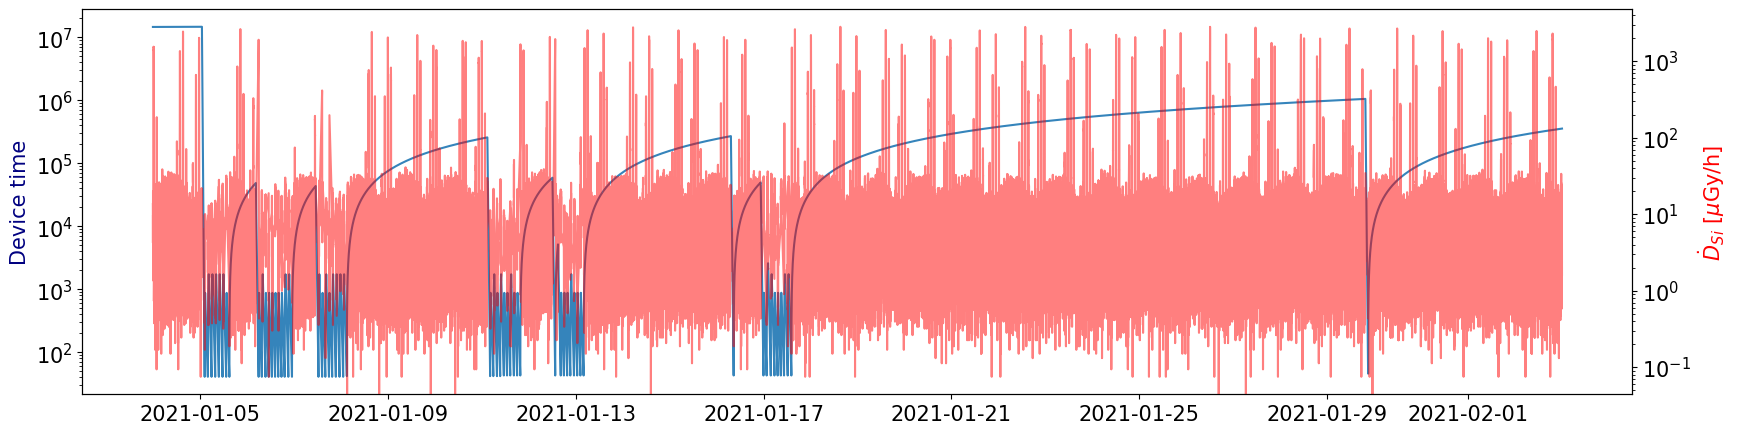

In [21]:
# --- zoom
tmin = pd.Timestamp("2020-10-14 00:00:00", tz="UTC") # Launch
tmin = pd.Timestamp("2020-12-14 00:00:00", tz="UTC")
tmin = pd.Timestamp("2021-01-04 00:00:00", tz="UTC") # 1st power interrupt
tmax = tmin + pd.Timedelta(days=30)
zoom = orbit.loc[orbit["UTC"] < tmax].loc[orbit["UTC"] > tmin]


plt.figure(figsize=(20,5))
matplotlib.rcParams.update({'font.size': 15})

ax1 = plt.gca()

zoom_data = rc.loc[rc["corr_time"] < tmax].loc[rc["corr_time"] > tmin]
ax1.plot(zoom_data["corr_time"], zoom_data['2'], label="Device time", alpha=0.9)
ax1.set_ylabel(r'Device time', color='navy')
ax1.set_yscale('log')

ax2 = ax1.twinx()

ax2.set_yscale('log')
#ax2.set_ylim(1,500)

zoom_data = rc.loc[rc["corr_time"] < tmax].loc[rc["corr_time"] > tmin]
ax2.plot(zoom_data["corr_time"], zoom_data["ddsi"], label="ddsi", color='red', alpha=0.5)
ax2.set_ylabel(r'$\.D$$_S$$_i$ [$\mu$Gy/h]', color='red')



Text(0, 0.5, '$\\.D$$_S$$_i$ [$\\mu$Gy/h]')

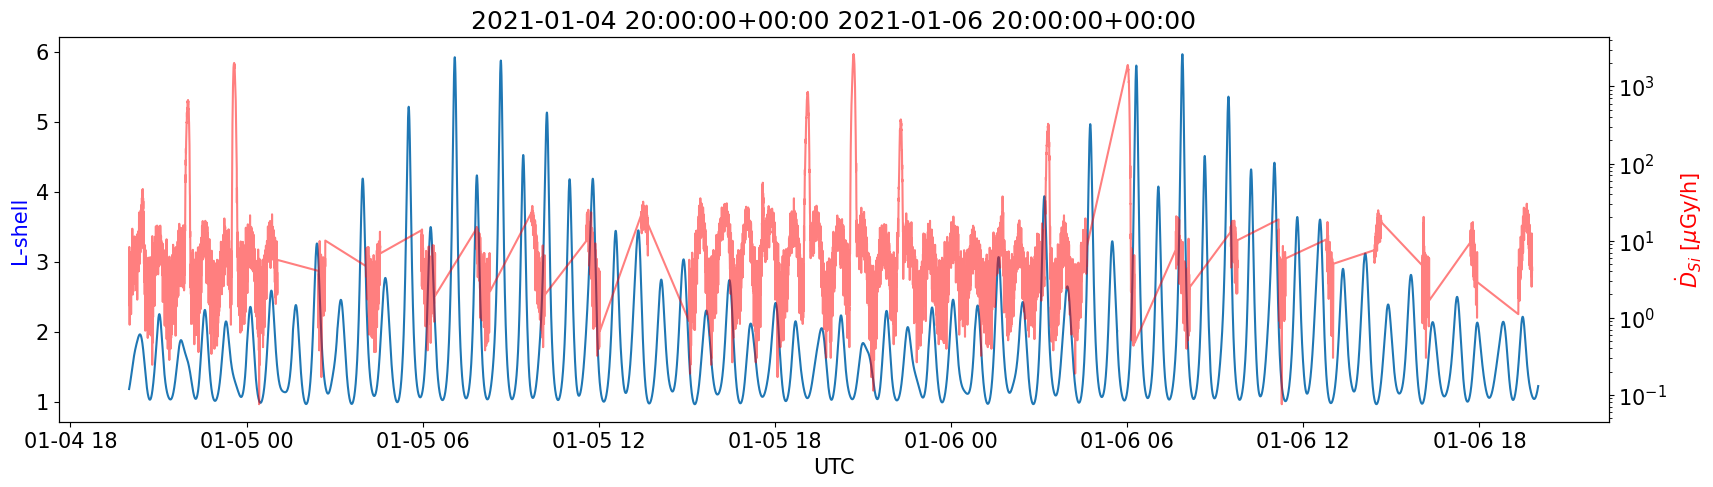

In [16]:
# --- zoom
tmin = pd.Timestamp("2020-10-14 00:00:00", tz="UTC") # Launch
tmin = pd.Timestamp("2020-12-14 00:00:00", tz="UTC")
tmin = pd.Timestamp("2021-01-04 20:00:00", tz="UTC") # 1st power break
tmax = tmin + pd.Timedelta(days=2)
zoom = orbit.loc[orbit["UTC"] < tmax].loc[orbit["UTC"] > tmin]


plt.figure(figsize=(20,5))
matplotlib.rcParams.update({'font.size': 15})

ax1 = plt.gca()
ax1.plot(zoom["UTC"], zoom["L"], label="L")
ax1.set_xlabel("UTC")
ax1.set_ylabel("L-shell", color='blue')
ax1.set_title(str(tmin)+" "+str(tmax))

# --- Docking time
mark_t = pd.Timestamp("2019-09-25 19:42:40", tz="UTC")
#ax1.axvline(mark_t, linestyle="--", linewidth=1)
#ax1.text(mark_t, ax1.get_ylim()[1], "Docking",
#         rotation=90, va="top", ha="right")

ax2 = ax1.twinx()

ax2.set_yscale('log')
#ax2.set_ylim(1,500)

zoom_data = rc.loc[rc["corr_time"] < tmax].loc[rc["corr_time"] > tmin]
ax2.plot(zoom_data["corr_time"], zoom_data["ddsi"], label="ddsi", color='red', alpha=0.5)
ax2.set_ylabel(r'$\.D$$_S$$_i$ [$\mu$Gy/h]', color='red')



## Save output to file

In [19]:
rc

,0,1,2,3,4,5,6,7,8,9,...,25,26,27,sum,time,ener,ddsi,abs_time,corr_time,flux
0,3,0,7509128.0,24782,259,0.0,13171.0,8008.0,38.0,0.0,...,0.0,0.0,0.0,1.0,7509128.0,228.0,0.112881,2020-10-13 08:03:04.437640+00:00,2020-10-13 08:03:04.437640+00:00,0.007958
1,4,1,7509139.0,24741,260,0.0,13478.0,7742.0,37.0,1.0,...,0.0,0.0,0.0,2.0,7509139.0,608.0,0.301017,2020-10-13 08:03:15.437860+00:00,2020-10-13 08:03:15.437860+00:00,0.015915
2,5,2,7509149.0,24606,259,1.0,14414.0,6954.0,24.0,1.0,...,0.0,0.0,0.0,1.0,7509149.0,152.0,0.075254,2020-10-13 08:03:25.438060+00:00,2020-10-13 08:03:25.438060+00:00,0.007958
3,6,3,7509160.0,24685,259,0.0,13871.0,7408.0,35.0,0.0,...,0.0,0.0,0.0,1.0,7509160.0,304.0,0.150508,2020-10-13 08:03:36.438280+00:00,2020-10-13 08:03:36.438280+00:00,0.007958
4,7,4,7509170.0,24585,260,3.0,14294.0,7088.0,29.0,0.0,...,0.0,0.0,0.0,1.0,7509170.0,190.0,0.094068,2020-10-13 08:03:46.438480+00:00,2020-10-13 08:03:46.438480+00:00,0.007958
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304795,1305081,60619,4875058.0,24444,259,13.0,16230.0,5199.0,62.0,26.0,...,2.0,0.0,0.0,52.0,21761517.0,16412.0,8.125470,2021-03-27 07:07:38.485419998+00:00,2021-03-27 07:07:38.485419998+00:00,0.413803
1304796,1305082,60620,4875069.0,24440,259,16.0,16042.0,5385.0,75.0,20.0,...,0.0,1.0,0.0,42.0,21761528.0,14816.0,7.335301,2021-03-27 07:07:49.485639999+00:00,2021-03-27 07:07:49.485639999+00:00,0.334225
1304797,1305083,60621,4875079.0,24460,259,4.0,16030.0,5401.0,61.0,26.0,...,0.0,1.0,0.0,44.0,21761538.0,14550.0,7.203606,2021-03-27 07:07:59.485839998+00:00,2021-03-27 07:07:59.485839998+00:00,0.350141
1304798,1305084,60622,4875090.0,24402,259,11.0,16327.0,5160.0,66.0,13.0,...,0.0,0.0,0.0,34.0,21761549.0,8550.0,4.233047,2021-03-27 07:08:10.486059999+00:00,2021-03-27 07:08:10.486059999+00:00,0.270563


In [ ]:
if (False):
  output_file = "SPACEDOS_ISS2020_corrected-power-interuptions.csv"
  rc.to_csv(output_file, index=False)